# kNN y Naive Bayes

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

import missingno as msno

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

In [3]:
def graf_histo_box_numericas(dataframe, var_num):
    """
    Realiza graficas histograma y boxplot de variables numéricas de un dataframe
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_num: lista de variables numéricas (cadena)

    -------------------------------
    SALIDA:
    No devuelve valor. Dibuja las gráficas por pantalla

    """

    TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
                   'tab:gray','tab:olive', 'tab:cyan')

    fig, axes = plt.subplots(len(var_num), 2, \
                             figsize=(20, 5 * len(var_num)), \
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    ax = axes.ravel()

    # graficas distribucion y boxplot de cada atributo
    for idx, atributo in enumerate(var_num):

        # distribucion (histograma)
        sns.histplot(dataframe[atributo], bins=30, ax=ax[2 * idx], \
                     color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                     alpha=0.15)

        # titulo, etiquetas histograma
        ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
        ax[2 * idx].set_xlabel(f'Valores {atributo}')
        ax[2 * idx].set_ylabel("Frequencia")

        # boxplot
        sns.boxplot(x=atributo, data=dataframe, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

        # titulo, etiquetas boxplot
        ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
        ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')

## Carga del dataset

Vamos a cargar el dataset de "iris". Scikit Learn disponde de varios [datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html) útiles para el aprendizaje:

In [4]:
# scikit proporciona datasets
from sklearn.datasets import load_iris


In [5]:
load_iris().keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
# devuelve atributos(X) y target (y) del dataframe
X, y = load_iris(return_X_y=True, as_frame=True)

# si lo necesito como DF
iris_df = X.copy()
iris_df['especie_iris'] = y

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_iris
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


\

El **target** consiste en las 3 clases de flores iris:

In [7]:
load_iris().target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

Los **atributos** son:

In [8]:
load_iris().feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

Formamos los nombre de las columnas:

In [9]:
# "arreglamos" nombres columnas atributos
columnas = [columna[:-5].replace(" ","_") for columna in iris_df.columns.to_list()]

columnas

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'especie']

In [10]:
iris_df.columns = columnas

iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,especie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Echemos un vistazo breve:

In [11]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   especie       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


\

Los **valores del target (numéricos)** se relacionan con el **orden del campo "target_names"**.

In [12]:
iris_df.especie.value_counts()

,count
especie,
0,50
1,50
2,50


In [13]:
load_iris().target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [14]:
iris_df.especie.value_counts()


,count
especie,
0,50
1,50
2,50


In [15]:
iris_df.especie = iris_df.especie.replace({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

iris_df.especie.value_counts()

,count
especie,
setosa,50
versicolor,50
virginica,50


\

## Explorar dataframe

In [16]:
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
# columna target ordenada.

iris_df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,especie
127,6.1,3.0,4.9,1.8,virginica
37,4.9,3.6,1.4,0.1,setosa
84,5.4,3.0,4.5,1.5,versicolor
20,5.4,3.4,1.7,0.2,setosa
139,6.9,3.1,5.4,2.1,virginica
114,5.8,2.8,5.1,2.4,virginica
144,6.7,3.3,5.7,2.5,virginica
117,7.7,3.8,6.7,2.2,virginica
26,5.0,3.4,1.6,0.4,setosa
71,6.1,2.8,4.0,1.3,versicolor


In [18]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


\

### Primeras gráficas

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


**TARGET**

<Axes: xlabel='especie', ylabel='count'>

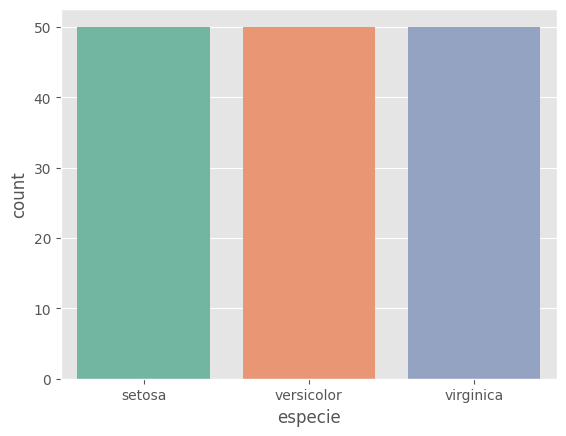

In [20]:
# SEABORN

sns.countplot(x='especie', data=iris_df,palette='Set2')

**ATRIBUTOS**

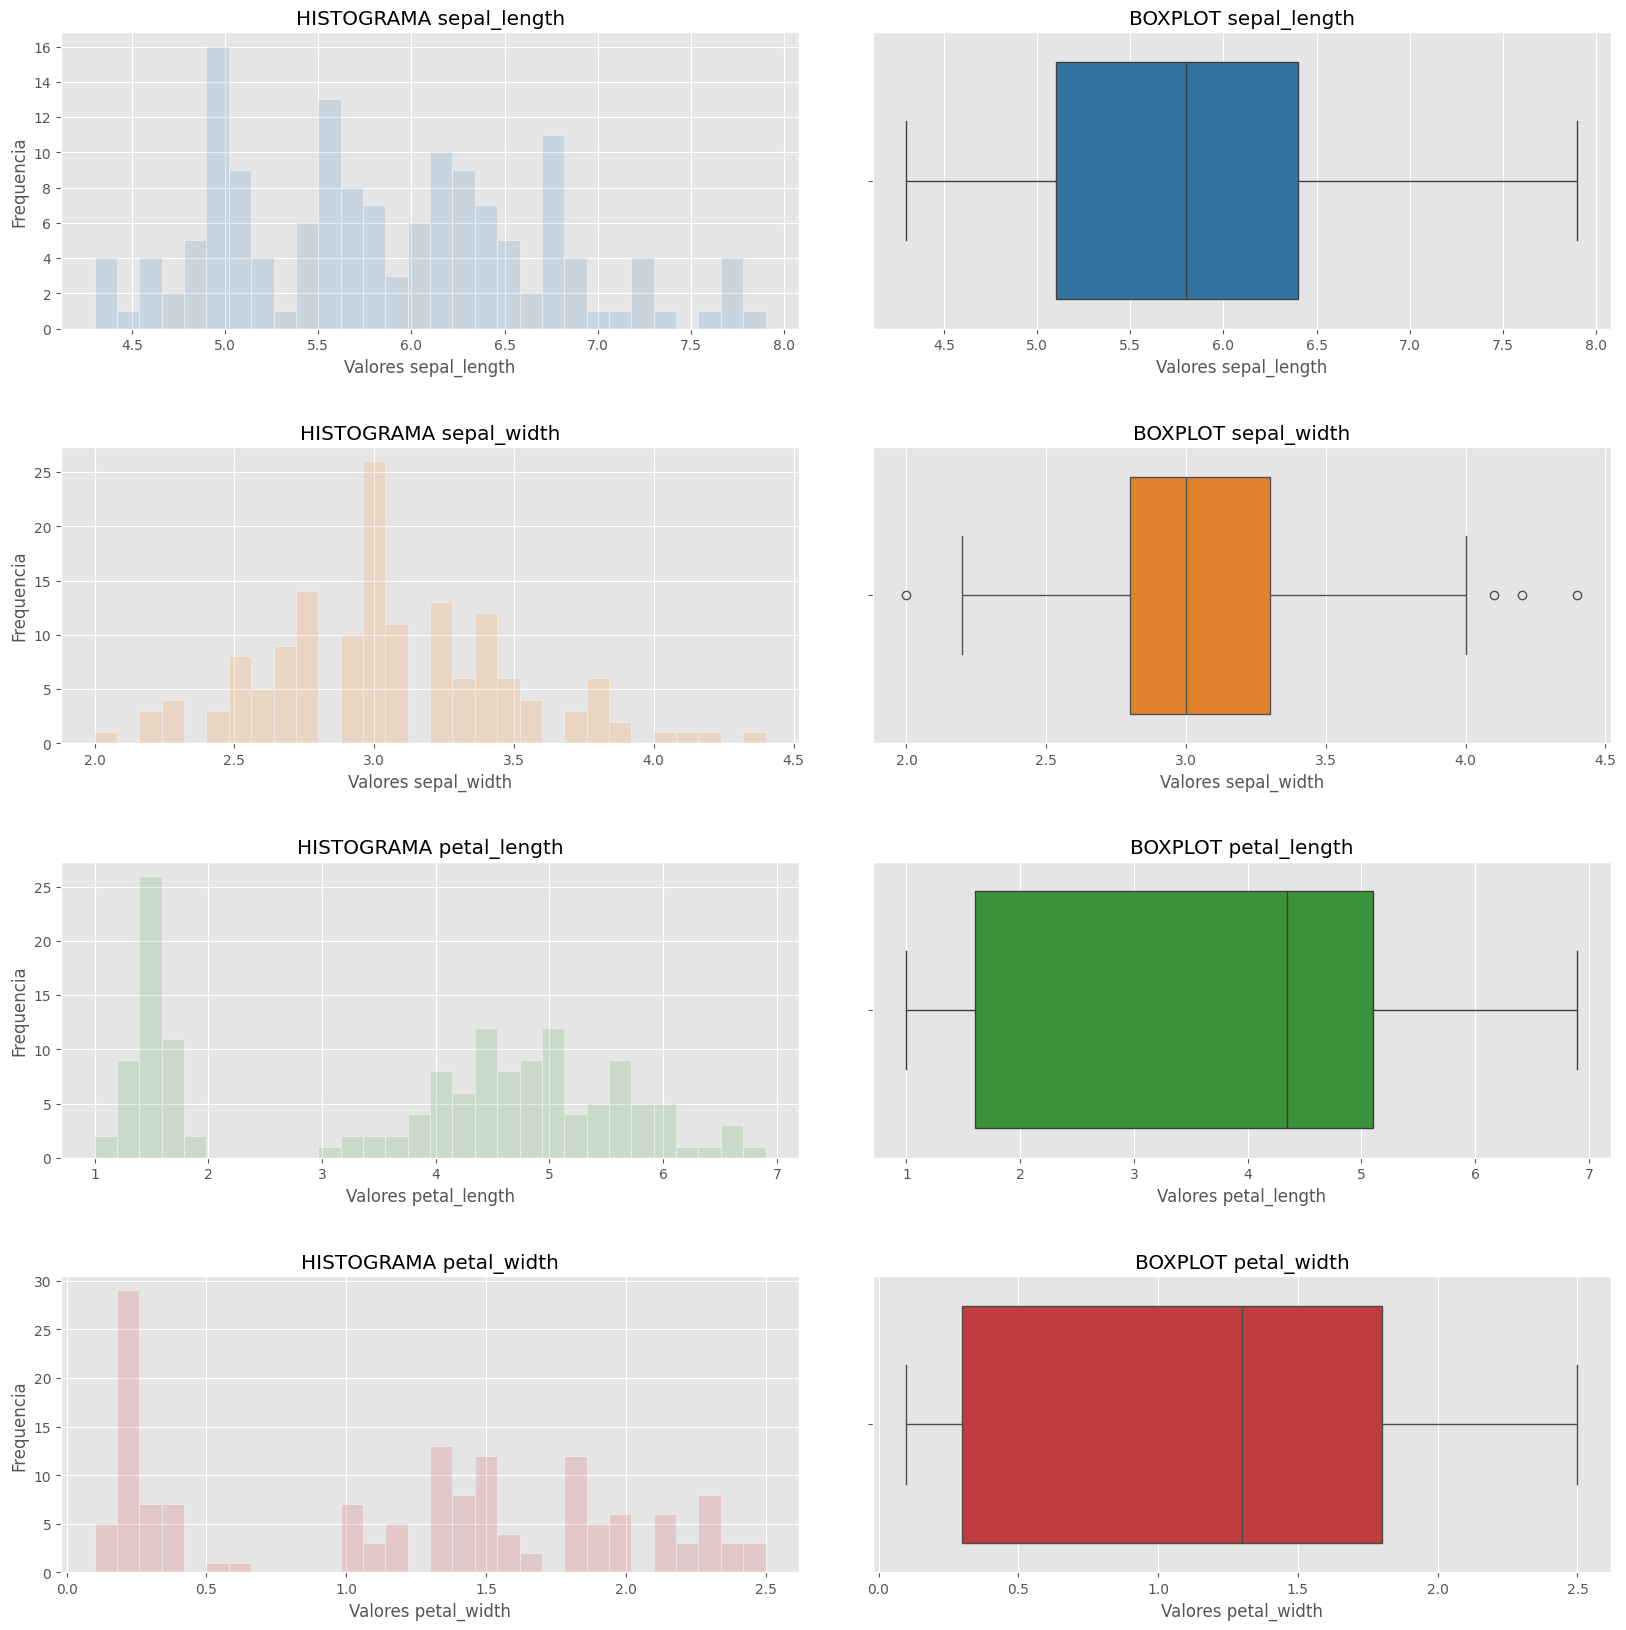

In [21]:
graf_histo_box_numericas(iris_df, ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

\

Por cuestiones didácticas y a la hora de **visualizar las fronteras de decisión en la clasificación para los distintos modelos (para comparar los modelos)**, vamos a buscar las 2 características que me permitan diferenciar más las clases (especies):

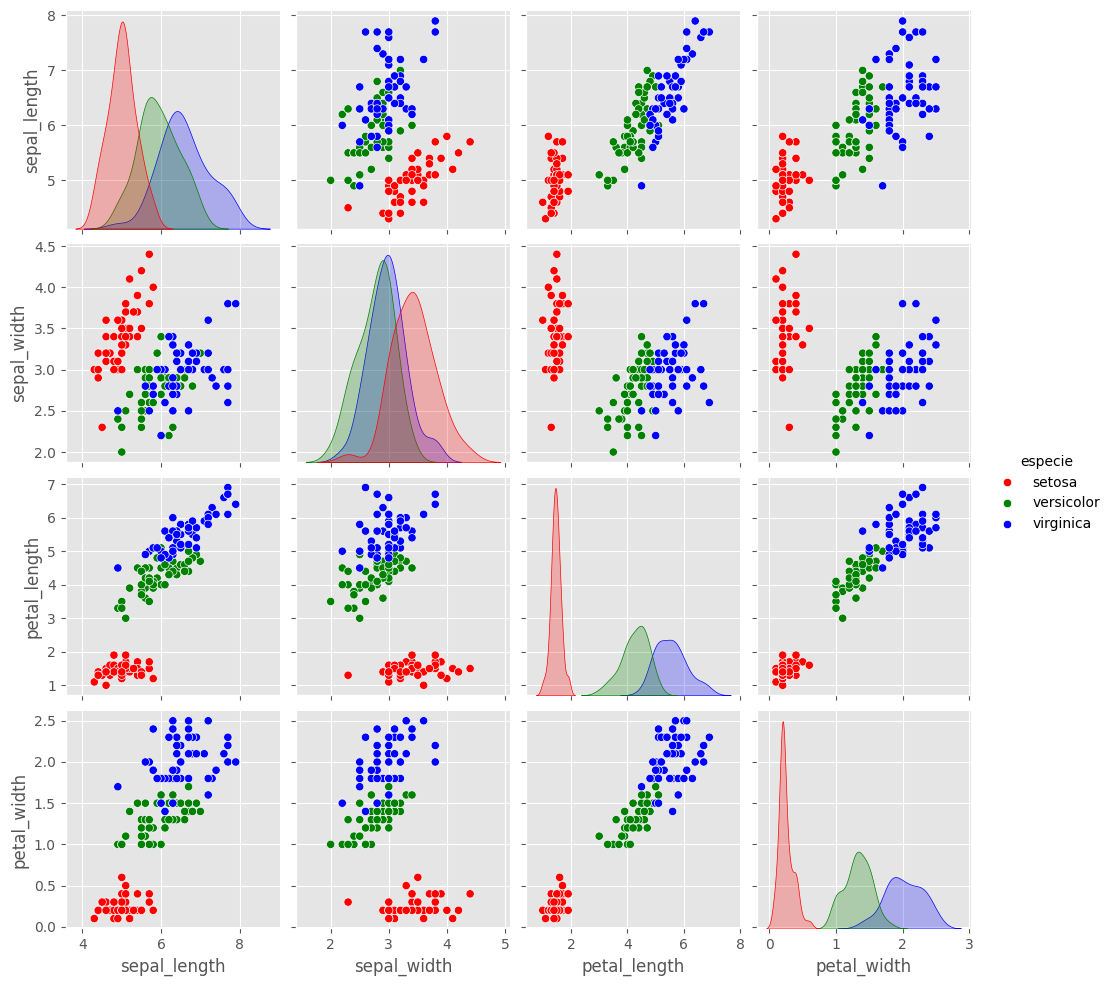

In [22]:
sns.pairplot(data=iris_df, hue='especie', palette={'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'})

**Podemos concluir que a la hora de elegir 2, son los atributos de los pétalos en donde se distinguen (se separan) más las clases**.

Las utilizaremos para comparar el desempeño de modelos y sacar conclusiones.

In [23]:
iris_df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'especie'],
      dtype='object')

\

## División TRAIN - TEST

In [24]:
from sklearn.model_selection import train_test_split


In [25]:
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,especie
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [26]:
# Separamos atributos y target:

X = iris_df.drop(columns='especie')

y = iris_df.especie

X.shape, y.shape

((150, 4), (150,))

**NOTA**: scikit learn **no trabaja con campos tipo texto**. La libreria proporciona "transformadores" para **codificar a numérico** (lo veremos más adelante).

Por ahora nos valdremos de usar método "map" sobre la "y":

In [27]:
load_iris().target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [28]:
y = y.map({'setosa': 0, 'versicolor': 1, 'virginica':2})

y.value_counts()

,count
especie,
0,50
1,50
2,50


Ahora si podemos pasar a la división TRAIN-TEST:

In [29]:
# division TRAIN-TEST

# queremos que haya la misma proporción de clases en TRAIN y TEST ===> parámetro "stratify"

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


In [30]:
X_train.shape, X_test.shape

((105, 4), (45, 4))

In [31]:
y_train.value_counts()

,count
especie,
1,35
0,35
2,35


In [32]:
y_test.value_counts()

,count
especie,
2,15
1,15
0,15


\

# k-Nearest Neighbours

## Entrenamiento. Predicción . Evaluación.

Para el parámetro más influyente de largo, el nº de vecinos (k), vamos primero a partir de valor (1), modelo complejo, e iremos incrementando valor para ver las distintas fases (entrenamiento, predicción, evaluación métrica por defecto)

In [33]:
# Instanciamos (creamos) el modelo:

from sklearn.neighbors import KNeighborsClassifier

clasif = KNeighborsClassifier(n_neighbors=1)



In [34]:
# lo entrenamos con la partición TRAIN

clasif.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

El **método "score"** utiliza como **métrica por defecto para clasificación "accuracy" (proporción de acierto)**.

**Una vez entrenado el modelo, lo evaluamos con la partición "test"**

**NOTA**: muchas veces se hace también con la partición TRAIN para comparar ambas y detectar señales de overfittting o underfitting

In [35]:
clasif.score(X_test, y_test)


0.9333333333333333

In [36]:
clasif.score(X_train, y_train)

1.0

**Que conclusiones podemos sacar?**

**Probamos con 3 vecinos, ¿ hacia donde nos movemos?**

In [37]:
clasif3 = KNeighborsClassifier(n_neighbors=3)

clasif3.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [38]:
clasif3.score(X_train,y_train)

0.9619047619047619

In [39]:
clasif3.score(X_test,y_test)

0.9555555555555556

Podemos **predecir de que tipo de flor** se trata si usamos el **método "predict"** y **le pasamos los atributos de la flor en cuestión**:



In [40]:
atributos_flor = np.array([[4.6, 3.1, 1.5, 0.2]])

clasif.predict(atributos_flor)

array([0])

In [41]:
clasif3.predict(atributos_flor)



array([0])

In [42]:
mi_prediccion = clasif3.predict(atributos_flor)

load_iris().target_names[mi_prediccion[0]]

np.str_('setosa')

\

Podemos comparar las predicciones para X_test con los valores reales (y_test) y volver a calcular el "accuracy":

In [43]:
clasif3.predict(X_test) == y_test

,especie
107,True
63,True
133,False
56,True
127,True
140,True
53,True
69,True
20,True
141,True


In [44]:
comprobar = clasif.predict(X_test) == y_test

comprobar.mean()

np.float64(0.9333333333333333)

## Comparación de modelos según "k". Fronteras de decisión

Nos vamos a valer de unas gráficas donde se visualizarán las fronteras de decisión para ver la influencia del parámetro "k".

Para ello nos va a hacer falta la siguiente **función** (**basta con utilizarla**):

In [45]:
from matplotlib.colors import ListedColormap


# Definimos la función que nos graficará las fronteras de decisión

def plot_decision_boundaries(model, X, y, delta: float = .02) -> None:
    """Plot data points and deicision boundaries learned by the model.

    Arguments:
    ----------
    model: scikit-learn like model

    X: np.array[n_samples, n_features]
        Only first 2 features will be considered because it is a 2d plot.
        Feature 0 in the x axis, and feature 1 in the y axis.

    y: np.array
        Labels for each sample.

    delta: float
        Increment between consecutive points when computing the grid for plotting boundaries.
        Lower value for higher resolution.
    """

    # Creamos la meshgrid con los valores mínimo y máximo de 'x' i 'y'.
    # La variable X es nuestro dataframe con las variables a estudiar (las del pétalo o las del sépalo)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, delta),
                         np.arange(y_min, y_max, delta))

    #Predecimos el clasificador con los valores de la meshgrid
    # En este caso model será nuestra variable que contiene el modelo a estudiar, es decir K-nn, SVM,...
    # Por ejemplo para K-nn sería model = KNeighborsClassifier()

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Creamos mapas de colores con ListedColormap para ver como separa las clases.
    # En este caso usaremos:
    # Iris-setosa : darkorange
    # Iris-versicolor: c
    # Iris-virginica: darkblue

    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ListedColormap(['darkorange', 'c', 'darkblue'])

    # Ponemos el resultado en una figura de color
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap= cmap_light)

    # Dibujamos también los puntos de entrenamiento
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap= cmap_bold)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

Para poder visualizarla en una gráfica 2D, elegiremos sólo 2 de los atributos. Si recuerdan los mejores atributos que "separaban" las clases eran las del pétalo ("petal_length", "petal_width"):

In [46]:
X.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

In [47]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X.iloc[:,2:], y, test_size=0.3,stratify=y, random_state=42)

In [48]:

k = [1,3,5,7]

modelos = []

for vecinos in k:

    clasif = KNeighborsClassifier(n_neighbors=vecinos)
    clasif.fit(X_train_f, y_train_f)

    modelos.append(clasif)


In [49]:
modelos[2]

KNeighborsClassifier()

Veamos las gráficas:

In [50]:
len(modelos)

4

**k = 1**

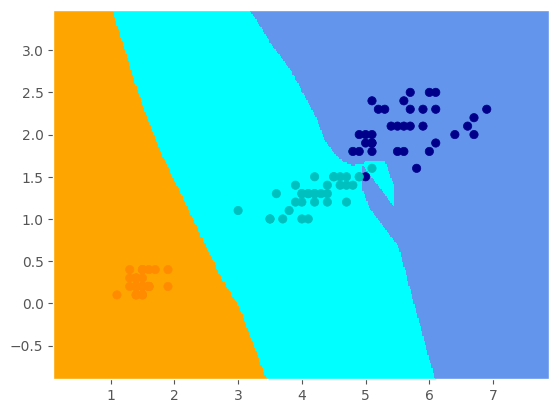

In [51]:
plot_decision_boundaries(modelos[0], X_train_f.values, y_train_f.values)

\

**k = 3**

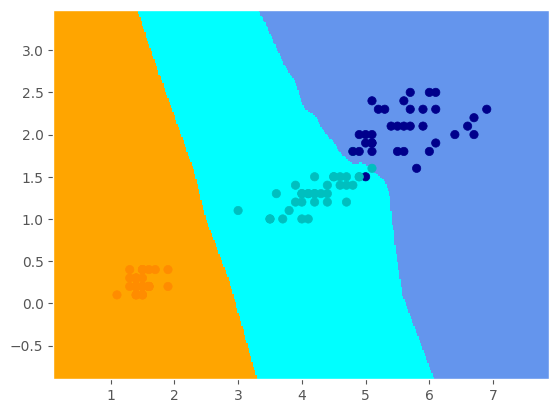

In [52]:
plot_decision_boundaries(modelos[1], X_train_f.values, y_train_f.values)

\

**k = 5**

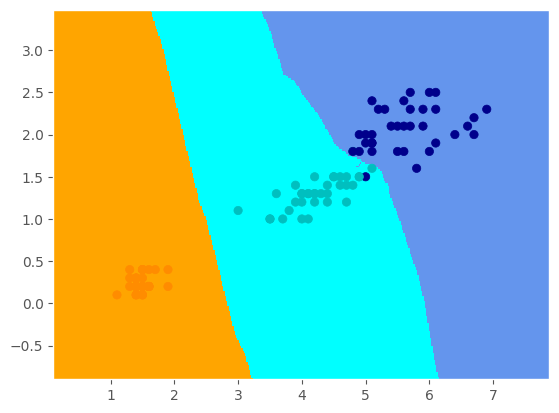

In [53]:
plot_decision_boundaries(modelos[2], X_train_f.values, y_train_f.values)

\

**k=7**

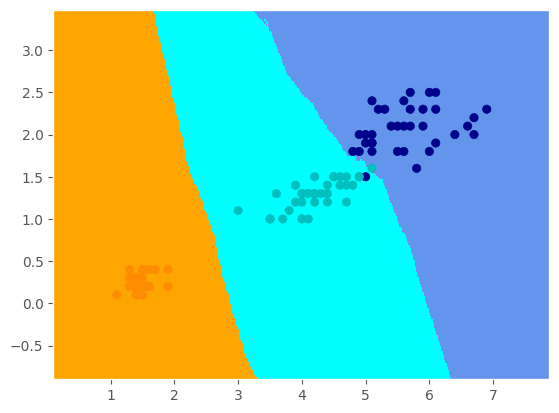

In [54]:
plot_decision_boundaries(modelos[3], X_train_f.values, y_train_f.values)

Vemos como **según aumenta "k" obteniendo modelos menos complejos, la segunda frontera de decisión** (la que vale la pena prestar atención) **se suaviza**.

\

# Naive Bayes

**NOTA**: no es necesario volver a hacer la partición TRAIN-TEST.

## Entrenamiento. Predicción . Evaluación.

Dadas las características de los datos que tenemos (**atributos continuos**) vamos a utilizar el modelo **"GaussianNB"**.

Para este modelo jugaremos con varios valores para el **parámetro "var_smoothing"** (proporción, entre cero y uno). **Según aumentamos** su valor vamos consiguiendo modelos menos complejos.

In [55]:
# Instanciamos (creamos) el modelo:

from sklearn.naive_bayes import GaussianNB

clasif = GaussianNB(var_smoothing=0.33)



In [56]:
# lo entrenamos con la partición TRAIN

clasif.fit(X_train, y_train)

GaussianNB(var_smoothing=0.33)

In [57]:
clasif.score(X_test, y_test)


0.8888888888888888

In [58]:
clasif.score(X_train, y_train)

0.9142857142857143

In [59]:
# Instanciamos (creamos) el modelo:

from sklearn.naive_bayes import GaussianNB

clasif = GaussianNB(var_smoothing=1)



In [60]:
# lo entrenamos con la partición TRAIN

clasif.fit(X_train, y_train)

GaussianNB(var_smoothing=1)

In [61]:
clasif.score(X_test, y_test)


0.8888888888888888

In [62]:
clasif.score(X_train, y_train)

0.9047619047619048

En este caso nos movemos en un rango muy pequeño y como se puede observar solo vemos diferencias yendonos a los extremos.Comprobamos que **si vamos utlizando modelos menos complejos** nos acercamos al valor de "var_smoothing" para el mejor desempeño (acc = 0.90 aprox.), si bien las diferencias no son grandes.

Pasamos a la **predicción**:



In [63]:
atributos_flor = np.array([[4.6, 3.1, 1.5, 0.2]])

clasif.predict(atributos_flor)

array([0])

In [64]:
load_iris().target_names[0]

np.str_('setosa')

\

De nuevo comparamos las predicciones para X_test con los valores reales (y_test) para volver a calcular el "accuracy":

In [65]:
clasif.predict(X_test) == y_test

,especie
107,True
63,True
133,False
56,True
127,False
140,True
53,True
69,True
20,True
141,True


In [66]:
comprobar = clasif.predict(X_test) == y_test

comprobar.mean()

np.float64(0.8888888888888888)

## Comparación de modelos según "var_smoothing". Fronteras de decisión

Visualizaremos las fronteras de decisión para ver la influencia del **parámetro "var_smoothing"**, usando la misma función para dibujarlas que con el modelo anterior "KNN"


Recordar que volveremos a utilizar sólo 2 de los atributos ("petal_length", "petal_width"), y no es necesario volver a calcular la partición opara este conjunto reducido:

In [67]:

var_sm = [1e-9, 0.33]

modelos = []

for v in var_sm:

    clasif = GaussianNB(var_smoothing=v)
    clasif.fit(X_train_f, y_train_f)

    modelos.append(clasif)



Veamos las gráficas:

**var_smoothing = 1e-9**

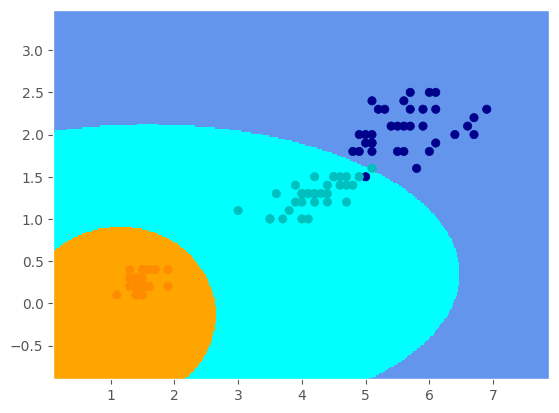

In [68]:
plot_decision_boundaries(modelos[0], X_train_f.values, y_train_f.values)

\

**var_smoothing = 0.33**

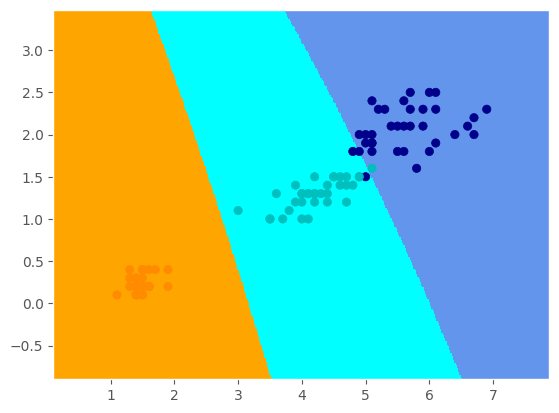

In [69]:
plot_decision_boundaries(modelos[1], X_train_f.values, y_train_f.values)

\

Vemos como **según aumenta "var_smoothing" obtenemos modelos menos complejos, con ambas fronteras de decisión** **muy suavizadas**.

\

# MANOS A LA OBRA:

El dataset **"wine"** es un dataset que recoge **multiples medidas de los niveles de sustancias químicas presentes en 3 clases de vino** (class_0,class_1, class_2).

**Todos los atributos son numéricos y podeis dejar el target como está (numérico)**

In [70]:
from sklearn.datasets import load_wine

X, y = load_wine(return_X_y=True, as_frame=True)

type(X), type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)

In [71]:
X.shape, y.shape

((178, 13), (178,))

In [72]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [73]:
X.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [74]:
y.unique()

array([0, 1, 2])

In [75]:
y.value_counts()

,count
target,
1,71
0,59
2,48


In [76]:
load_wine().keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [77]:
load_wine().target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

\

## EJERCICIO:

1.- "Construir" el dataframe con atributos y target.

2.- Realizar la partición TRAIN-TEST

3.- Entrenar modelos "k-NN" para al menos 2 valores de "k". Comparar los valores de "accuracy" (TRAIN y TEST) entre modelos

4.- Entrenar modelos "NB" para al menos 2 valores de "var_smoothing". Comparar los valores de "accuracy" (TRAIN y TEST) entre modelos.

**NO ES NECESARIO** dibujar las fronteras de decisión

In [78]:
# Combinar X y y en un solo dataframe
wine_df = X.copy()
wine_df['target'] = y

# Mostrar las primeras filas del dataframe
display(wine_df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [79]:
# Separar atributos (X) y target (y) para la división
X_wine = wine_df.drop(columns='target')
y_wine = wine_df.target

# Realizar la partición TRAIN-TEST
# Usamos stratify para mantener la proporción de clases en ambos conjuntos
from sklearn.model_selection import train_test_split

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.3, stratify=y_wine, random_state=42)

print("Dimensiones de los conjuntos de entrenamiento:")
print("X_train:", X_train_wine.shape)
print("y_train:", y_train_wine.shape)
print("\nDimensiones de los conjuntos de prueba:")
print("X_test:", X_test_wine.shape)
print("y_test:", y_test_wine.shape)

Dimensiones de los conjuntos de entrenamiento:
X_train: (124, 13)
y_train: (124,)

Dimensiones de los conjuntos de prueba:
X_test: (54, 13)
y_test: (54,)


In [80]:
from sklearn.neighbors import KNeighborsClassifier

# Definir los valores de k a probar
k_values = [3, 7] # Puedes añadir más valores si deseas

# Listas para almacenar los modelos y sus accuracies
knn_models = {}
knn_accuracies_train = {}
knn_accuracies_test = {}

for k in k_values:
    # Instanciar el modelo k-NN
    clasif_knn = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clasif_knn.fit(X_train_wine, y_train_wine)

    # Almacenar el modelo
    knn_models[f'k={k}'] = clasif_knn

    # Evaluar el modelo en TRAIN y TEST
    accuracy_train = clasif_knn.score(X_train_wine, y_train_wine)
    accuracy_test = clasif_knn.score(X_test_wine, y_test_wine)

    # Almacenar las accuracies
    knn_accuracies_train[f'k={k}'] = accuracy_train
    knn_accuracies_test[f'k={k}'] = accuracy_test

# Mostrar los resultados
print("Accuracy de los modelos k-NN en el conjunto de entrenamiento:")
for k, acc in knn_accuracies_train.items():
    print(f"{k}: {acc:.4f}")

print("\nAccuracy de los modelos k-NN en el conjunto de prueba:")
for k, acc in knn_accuracies_test.items():
    print(f"{k}: {acc:.4f}")

Accuracy de los modelos k-NN en el conjunto de entrenamiento:
k=3: 0.8548
k=7: 0.7742

Accuracy de los modelos k-NN en el conjunto de prueba:
k=3: 0.6852
k=7: 0.7407


In [85]:
from sklearn.naive_bayes import GaussianNB

# Definir los valores de var_smoothing a probar
var_smoothing_values = [1e-9, 0.5] # Puedes añadir más valores si deseas

# Listas para almacenar los modelos y sus accuracies
nb_models = {}
nb_accuracies_train = {}
nb_accuracies_test = {}

for vs in var_smoothing_values:
    # Instanciar el modelo Naive Bayes (GaussianNB para datos continuos)
    clasif_nb = GaussianNB(var_smoothing=vs)

    # Entrenar el modelo
    clasif_nb.fit(X_train_wine, y_train_wine)

    # Almacenar el modelo
    nb_models[f'var_smoothing={vs}'] = clasif_nb

    # Evaluar el modelo en TRAIN y TEST
    accuracy_train = clasif_nb.score(X_train_wine, y_train_wine)
    accuracy_test = clasif_nb.score(X_test_wine, y_test_wine)

    # Almacenar las accuracies
    nb_accuracies_train[f'var_smoothing={vs}'] = accuracy_train
    nb_accuracies_test[f'var_smoothing={vs}'] = accuracy_test

# Mostrar los resultados
print("Accuracy de los modelos Naive Bayes en el conjunto de entrenamiento:")
for vs, acc in nb_accuracies_train.items():
    print(f"{vs}: {acc:.4f}")

print("\nAccuracy de los modelos Naive Bayes en el conjunto de prueba:")
for vs, acc in nb_accuracies_test.items():
    print(f"{vs}: {acc:.4f}")

Accuracy de los modelos Naive Bayes en el conjunto de entrenamiento:
var_smoothing=1e-09: 0.9677
var_smoothing=0.5: 0.6532

Accuracy de los modelos Naive Bayes en el conjunto de prueba:
var_smoothing=1e-09: 1.0000
var_smoothing=0.5: 0.6667
